### 📊 CRM Sales, Rental & Service Lead Analysis  
**Real-World Business Dataset | EDA | Data Cleaning | Insights**

This notebook analyzes a real company CRM dataset containing Sales, Rental, and Service leads.  
Objective: Clean the data, perform exploratory analysis, and generate insights for business decision-making.

In [1]:
# Cell 1 — Import + Load Raw File
import pandas as pd
import numpy as np
from collections import Counter
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

df = pd.read_excel("ToStudent_Leads-Feb2023toDec2024.xlsx")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 19298, Columns: 35


,assigner,assignee,LID,Lead By,Last Engaged,Lead Date,Vertical,Column Break,Company/Name,PTC Name,Column Break2,Column Break3,Town,District,State/UT,Column Break4,Source,Source Category,Product,Services,Walkin Services,Rental,Project,Remarks,Status,Column Break5,Next Followup,NF Time,NF Age,Column Break6,Deal Value,Sale Date,Priority,Last Contact,Remarks 2
0,NaN,NaN,L021417,Ligin Thrissur Branch,NaN,07-12-2024 17:19:00,Services,NaN,PRADEEP MASTER,PRADEEP MASTER,NaN,NaN,THRISSUR,Thrissur,Kerala,NaN,Existing Customer,Customer,NaN,Laptop Service,NaN,NaN,NaN,NaN,#5 Sold,NaN,NaN,NaN,Y:M:D,NaN,1700.0,07-12-2024,NaN,NaN,NaN
1,NaN,NaN,L021416,Sajith Kumar S,NaN,07-12-2024 17:18:00,Rental,NaN,Shajil,SHAJIL ABDUL AZEEZ,NaN,NaN,Trivandrum,Thiruvananthapuram,Kerala,NaN,Existing Customer,Customer,NaN,NaN,NaN,Laptop - Rent,NaN,RENTED FOR 1 MONTH,#5 Sold,NaN,NaN,NaN,Y:M:D,NaN,2596.0,07-12-2024,Normal,NaN,NaN
2,NaN,NaN,L021415,Sajith Kumar S,NaN,07-12-2024 17:16:00,Rental,NaN,VINOD S,VINOD S,NaN,NaN,Ooruttambalam,Thiruvananthapuram,Kerala,NaN,Walkin,Walkin,NaN,NaN,NaN,Laptop - Rent,NaN,RENTED FOR 1 DAY & PAYMENT RECEIVED,#5 Sold,NaN,NaN,NaN,Y:M:D,NaN,1593.0,07-12-2024,Normal,NaN,NaN
3,NaN,NaN,L021414,Ligin Thrissur Branch,NaN,07-12-2024 17:16:00,Rental,NaN,SUMI K S,SUMI K S,NaN,NaN,THRISSUR,Thrissur,Kerala,NaN,Shimjith Methatta,Management,NaN,NaN,NaN,Laptop - Rent,NaN,NaN,#5 Sold,NaN,NaN,NaN,Y:M:D,NaN,2065.0,07-12-2024,NaN,NaN,NaN
4,NaN,NaN,L021413,Shinoj T,NaN,07-12-2024 16:06:00,Rental,NaN,Dipin p,Dipin p,NaN,NaN,Calicut,Kozhikode,Kerala,NaN,Regular Customer,Customer,NaN,NaN,NaN,Laptop - Rent,NaN,NaN,#5 Sold,NaN,NaN,NaN,Y:M:D,NaN,3540.0,07-12-2024,NaN,NaN,NaN


In [2]:
# Cell 2 — Quick structure & null overview
# Show columns, dtypes and top null counts to understand what's missing
print("Columns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nTop null counts:")
print(df.isnull().sum().sort_values(ascending=False).head(30))


Columns: ['assigner', 'assignee', 'LID', 'Lead By', 'Last Engaged', 'Lead Date', 'Vertical', 'Column Break', 'Company/Name', 'PTC Name', 'Column Break2', 'Column Break3', 'Town', 'District', 'State/UT', 'Column Break4', 'Source', 'Source Category', 'Product', 'Services', 'Walkin Services', 'Rental', 'Project', 'Remarks', 'Status', 'Column Break5', 'Next Followup', 'NF Time', 'NF Age', 'Column Break6', 'Deal Value', 'Sale Date', 'Priority', 'Last Contact', 'Remarks 2']

Dtypes:
assigner            object
assignee            object
LID                 object
Lead By             object
Last Engaged        object
Lead Date           object
Vertical            object
Column Break       float64
Company/Name        object
PTC Name            object
Column Break2      float64
Column Break3      float64
Town                object
District            object
State/UT            object
Column Break4      float64
Source              object
Source Category     object
Product             object
Servi

In [3]:
# Cell 3 — Basic cleanup: strip column names and standardize
# Convert column names to snake_case-ish (preserves readability)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')
df.columns = [c.strip() for c in df.columns]
print("Cleaned column names:")
print(df.columns.tolist())


Cleaned column names:
['assigner', 'assignee', 'LID', 'Lead_By', 'Last_Engaged', 'Lead_Date', 'Vertical', 'Column_Break', 'Company_Name', 'PTC_Name', 'Column_Break2', 'Column_Break3', 'Town', 'District', 'State_UT', 'Column_Break4', 'Source', 'Source_Category', 'Product', 'Services', 'Walkin_Services', 'Rental', 'Project', 'Remarks', 'Status', 'Column_Break5', 'Next_Followup', 'NF_Time', 'NF_Age', 'Column_Break6', 'Deal_Value', 'Sale_Date', 'Priority', 'Last_Contact', 'Remarks_2']


In [4]:
# Cell 4 — Drop clearly unwanted helper columns 
# If those columns do not exist skip silently
cols_to_drop = [
    'Remarks_2', 'Column_Break6', 'Column_Break', 'Column_Break5',
    'Column_Break2', 'Column_Break3', 'Column_Break4',
    'Last_Engaged', 'assigner', 'assignee'
]
cols_present = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_present)
print("Dropped helper columns (if they existed):", cols_present)



Dropped helper columns (if they existed): ['Remarks_2', 'Column_Break6', 'Column_Break', 'Column_Break5', 'Column_Break2', 'Column_Break3', 'Column_Break4', 'Last_Engaged', 'assigner', 'assignee']


In [5]:
# Cell 5 — Drop NF_Time and NF_Age 
for c in ["NF_Time", "NF_Age"]:
    if c in df.columns:
        df = df.drop(columns=[c])
        print(f"Dropped {c}")


Dropped NF_Time
Dropped NF_Age


In [6]:
# Cell 6 — Convert date columns properly (dayfirst=True for DD-MM-YYYY)
date_cols = [c for c in ["Lead_Date", "Next_Followup", "Sale_Date", "Last_Contact"] if c in df.columns]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
print("Converted date columns:", date_cols)


Converted date columns: ['Lead_Date', 'Next_Followup', 'Sale_Date', 'Last_Contact']


In [7]:
# Cell 7 — Clean whitespace in key text columns & normalize case where appropriate
text_cols = [c for c in df.columns if df[c].dtype == "object"]
# strip spaces and replace multiple spaces
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})
# For columns where we want consistent Title Case (districts/company), do later per-column
print("Stripped whitespace for text columns. Sample values:")
for c in ["Source_Category", "Product", "Services"] :
    if c in df.columns:
        print(c, df[c].dropna().unique()[:5])


Stripped whitespace for text columns. Sample values:
Source_Category ['Customer' 'Walkin' 'Management' 'Staff' 'STAFF']
Product ['Projector sales' 'Toshiba I5 6th 8 GB 512 SSD' 'Accessories'
 'Laptop Sale' 'CCTV Service']
Services ['Laptop Service' 'Desktop Service' 'Networking' 'Printer Service'
 'Tonner Refilling']


In [8]:
# Cell 8 — Town/District/State handling: drop Town (Total Error)
if 'Town' in df.columns:
    df = df.drop(columns=['Town'])
    print("Dropped Town column (contains many errors)")

# Replace negative revenue values (e.g., -1) with 0
df["Deal_Value"] = df["Deal_Value"].apply(lambda x: 0 if pd.notna(x) and x < 0 else x)

print("Negative Deal_Value values corrected.")
print(df["Deal_Value"].describe())


Dropped Town column (contains many errors)
Negative Deal_Value values corrected.
count    1.929800e+04
mean     1.449893e+04
std      2.669320e+05
min      0.000000e+00
25%      0.000000e+00
50%      7.500000e+02
75%      3.540000e+03
max      3.014900e+07
Name: Deal_Value, dtype: float64


In [9]:
# Cell 9 — District mapping (normalize names & remove junk)
# First: normalize District strings, convert obvious placeholders to NaN,
# and apply manual typo fixes (title-cased final values for display).
if 'District' in df.columns:
    # normalize to string, strip whitespace
    df['District'] = df['District'].astype(str).str.strip()

    # Treat literal string placeholders as missing
    df['District'].replace({'nan': np.nan, 'none': np.nan, '': np.nan, 'NaN': np.nan}, inplace=True)

    # Common manual fixes (expand as you find more)
    district_fix = {
        'CHERTHALA': 'Alappuzha', 'ALAPPUZHA': 'Alappuzha', 'ALAPPUZHA ': 'Alappuzha',
        'BANGLORE': 'Bangalore', 'EARNAKULAM': 'Ernakulam', 'ERNAKULAM': 'Ernakulam',
        'PATHAMTHITTA': 'Pathanamthitta', 'PATHANAMTHITTA': 'Pathanamthitta',
        'THRISSUR': 'Thrissur', 'TRISSUR': 'Thrissur',
        'KOZHIKODE': 'Kozhikode', 'CALICUT': 'Kozhikode',
        'Velachery': 'Chennai', 'Marayoor': 'Idukki', 'kannur': 'Kannur',
        'Puduchery': 'Puducherry'
    }

    # Replace known typos / variants (case-insensitive application)
    # create mapping keys normalized to same case to match possible inputs
    normalized_fix = {}
    for k, v in district_fix.items():
        normalized_fix[k.strip()] = v

    # Apply replacements (works even if original values are mixed-case)
    df['District'] = df['District'].replace(normalized_fix)

    # Remove small junk localities if present (do not drop rows; mark as NaN)
    junk_localities = ['Nehrunagar', 'Kapur']
    df.loc[df['District'].isin(junk_localities), 'District'] = np.nan

    # If a state name accidentally exists in District (e.g., 'Tamil Nadu', 'Kerala'),
    # treat that as missing district (we'll map state later)
    state_names = ['Kerala', 'Tamil Nadu', 'Karnataka', 'Maharashtra', 'Delhi', 'Puducherry']
    # match case-insensitively
    df.loc[df['District'].str.strip().str.lower().isin([s.lower() for s in state_names]), 'District'] = np.nan

    # Normalize title-case for display (keeping NaN intact)
    df['District'] = df['District'].apply(lambda x: x.title() if isinstance(x, str) else x)

    # Report summary
    print("District unique after basic fixes:", df['District'].nunique(dropna=True))
    print("Sample District values after fixes:")
    display(df['District'].dropna().unique()[:40])
else:
    print("No 'District' column found in df.")


District unique after basic fixes: 39
Sample District values after fixes:


C:\Users\gokul\AppData\Local\Temp\ipykernel_35592\1257792847.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['District'].replace({'nan': np.nan, 'none': np.nan, '': np.nan, 'NaN': np.nan}, inplace=True)


array(['Thrissur', 'Thiruvananthapuram', 'Kozhikode', 'Kannur',
       'Ernakulam', 'Malappuram', 'Palakkad', 'Bangalore', 'Kollam',
       'Pathanamthitta', 'Alappuzha', 'Kottayam', 'Kasaragod', 'Wayanad',
       'Kodagu', 'Idukki', 'Kanniyakumari', 'Coimbatore', 'Chitradurga',
       'Mysore', 'Chennai', 'Krishnagiri', 'Mumbai', 'Tirunelveli',
       'Kolar', 'Bidar', 'Dharwad', 'Dharmapuri', 'Madurai', 'Tumkur',
       'Bellary', 'Gulbarga', 'Bijapur', 'Virudhunagar', 'Uttara Kannada',
       'Salem', 'Belgaum', 'Viluppuram', 'Erode'], dtype=object)

In [10]:
# Cell 10 — District -> State mapping (map districts to states, report unmapped)
# Define mapping (no duplicate keys). Add missing districts as you discover them.
district_to_state = {
    # Kerala
    'Alappuzha': 'Kerala', 'Ernakulam': 'Kerala', 'Kollam': 'Kerala',
    'Kottayam': 'Kerala', 'Kozhikode': 'Kerala', 'Kannur': 'Kerala',
    'Malappuram': 'Kerala', 'Palakkad': 'Kerala', 'Pathanamthitta': 'Kerala',
    'Thrissur': 'Kerala', 'Thiruvananthapuram': 'Kerala', 'Wayanad': 'Kerala',
    'Idukki': 'Kerala', 'Kasaragod': 'Kerala',

    # Tamil Nadu
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Dharmapuri': 'Tamil Nadu',
    'Erode': 'Tamil Nadu', 'Kanniyakumari': 'Tamil Nadu', 'Krishnagiri': 'Tamil Nadu',
    'Madurai': 'Tamil Nadu', 'Salem': 'Tamil Nadu', 'Tirunelveli': 'Tamil Nadu',
    'Viluppuram': 'Tamil Nadu', 'Virudhunagar': 'Tamil Nadu',

    # Karnataka
    'Bangalore': 'Karnataka', 'Mysore': 'Karnataka', 'Dharwad': 'Karnataka',
    'Bellary': 'Karnataka', 'Gulbarga': 'Karnataka', 'Bidar': 'Karnataka',
    'Kodagu': 'Karnataka', 'Chitradurga': 'Karnataka', 'Tumkur': 'Karnataka',
    'Uttara Kannada': 'Karnataka', 'Kolar': 'Karnataka', 'Belgaum': 'Karnataka',
    'Bijapur': 'Karnataka',

    # Maharashtra / Others
    'Mumbai': 'Maharashtra', 'Delhi': 'Delhi', 'Puducherry': 'Puducherry'
}

if 'District' in df.columns:
    # Map District -> State_UT (will produce NaN for unknown/unmapped districts)
    df['State_UT'] = df['District'].map(district_to_state)

    # Report mapped states and unmapped districts for review
    mapped_states = sorted(df['State_UT'].dropna().unique())
    unmapped = sorted(df.loc[df['State_UT'].isna(), 'District'].dropna().unique())

    print("Mapped State_UT unique values:", mapped_states)
    print("Unmapped districts (please review):", unmapped)
    print("Count unmapped rows:", int(df['State_UT'].isna().sum()))

    # Show a small sample of rows that are unmapped (for manual inspection)
    sample_unmapped = df.loc[df['State_UT'].isna(), ['District', 'State_UT']].drop_duplicates().head(20)
    if not sample_unmapped.empty:
        print("\nSample unmapped rows (District column):")
        display(sample_unmapped)
    else:
        print("\nNo unmapped district sample to show.")

    # Optional: create flags so EDA can treat unmapped separately (do not overwrite)
    df['District_Mapped_Flag'] = np.where(df['State_UT'].notna(), 'mapped', 'unmapped')
    print("\nDistrict_Mapped_Flag value counts:")
    print(df['District_Mapped_Flag'].value_counts(dropna=False))
else:
    print("No 'District' column present.")


Mapped State_UT unique values: ['Karnataka', 'Kerala', 'Maharashtra', 'Tamil Nadu']
Unmapped districts (please review): []
Count unmapped rows: 105

Sample unmapped rows (District column):


,District,State_UT
5,NaN,NaN



District_Mapped_Flag value counts:
District_Mapped_Flag
mapped      19193
unmapped      105
Name: count, dtype: int64


In [11]:
# Cell 11 — Source_Category cleanup (consolidate staff / referrals / digital)
if 'Source_Category' in df.columns:
    source_mapping = {
        "Customer": "Customer", "REGULAR CUSTOMER": "Customer",
        "Walkin": "Walk-in", "Feedback call": "Feedback", "on call": "Phone Call",
        "existing": "Existing Customer",
        "Staff": "Staff", "STAFF": "Staff", "staff": "Staff",
        "Management": "Management",
        "Balachandar P": "Staff Referral", "RESHMI": "Staff Referral", "Ashwin": "Staff Referral",
        "ARUN": "Staff Referral", "LIGIN": "Staff Referral", "Joshua Xavier": "Staff Referral",
        "Sulekha": "Digital Platform",
        "Google": "Google", "Just Dial": "Justdial", "WhatsApp": "WhatsApp",
        "Youtube": "YouTube", "Instagram": "Instagram", "Facebook": "Facebook",
        "India Mart": "Indiamart", "Email": "Email",
        "Newspaper": "Newspaper", "Ads": "Advertisement", "Event": "Event",
        "BNI": "BNI", "other referral": "Referral", "Collab": "Collaboration",
        "GemPortal": "Government Portal", "GEM": "Government Portal",
        "cover tender": "Tender", "Tender": "Tender", "CUSAT - Sight": "CUSAT",
        "GEM ADS": "Government Portal", "Gem Ads": "Government Portal"
    }
    df['Source_Category'] = df['Source_Category'].replace(source_mapping)
    print("Source_Category unique now:", df['Source_Category'].nunique())


Source_Category unique now: 26


In [12]:
# Cell 12 — Product: normalize & explode multi-items temporarily (no leftover columns)
# Normalize product as title case, split on '||' or '|' if multi items exist,
# categorize items and then aggregate back to a single category per original row.
def normalize_prod(text):
    if pd.isna(text) or str(text).strip() == "" or str(text).lower() in ['nan', 'none']:
        return np.nan
    # remove excessive whitespace and unify separators
    t = str(text).strip()
    t = t.replace('||', '|').replace('  ', ' ')
    return t

df['Product_raw'] = df['Product'].apply(normalize_prod) if 'Product' in df.columns else np.nan
# Create temp exploded frame only if Product_raw exists
if 'Product_raw' in df.columns:
    df['_row_id'] = df.index
    df['Product_list_temp'] = df['Product_raw'].fillna('').str.split('|')
    df_long = df.explode('Product_list_temp').reset_index(drop=True)
    df_long['Product_list_temp'] = df_long['Product_list_temp'].astype(str).str.strip().replace({'': np.nan})
    print("Exploded product rows:", df_long.shape[0])
else:
    df_long = df.copy()


Exploded product rows: 19361


In [13]:
# Cell 13 — Categorize products (rule-based), then collapse to one category per row
def txt_lower(x):
    return str(x).lower() if pd.notna(x) else ""

def categorize_product_item(item):
    t = txt_lower(item)
    if not t or t in ['nan','none']:
        return np.nan
    if "laptop" in t or "notebook" in t:
        return "Laptop Sales"
    if "desktop" in t or t.startswith("pc"):
        return "Desktop Sales"
    if any(k in t for k in ["ram","ssd","hard disk","hdd","memory","pendrive","pen drive"]):
        return "Storage & Memory"
    if any(k in t for k in ["cctv","camera","dvr","nvr","hikvision","ezviz","cctv camera"]):
        return "CCTV & Surveillance"
    if any(k in t for k in ["printer","cartridge","toner","plotter","epson","canon","xerox"]):
        return "Printer & Accessories"
    if any(k in t for k in ["projector","screen","projector screen"]):
        return "Projector & Screens"
    if any(k in t for k in ["router","switch","network","access point","cable","cat6"]):
        return "Networking & Switches"
    if any(k in t for k in ["windows","license","antivirus","microsoft","software","tally"]):
        return "Software & Licenses"
    if any(k in t for k in ["service","installation","repair","maintenance","config","setup"]):
        return "Services"
    if any(k in t for k in ["motherboard","processor","cpu","graphics","gpu","smps","cabinet"]):
        return "Components"
    if any(k in t for k in ["ups","battery","inverter","pdu"]):
        return "Power & UPS"
    if any(k in t for k in ["keyboard","mouse","headset","bag","adapter","cable","stand","monitor"]):
        return "Accessories"
    return "Others"

if 'Product_list_temp' in df_long.columns:
    df_long['Product_cat_temp'] = df_long['Product_list_temp'].apply(categorize_product_item)
    # choose the most frequent category among exploded items per original row
    prod_cat = (df_long.groupby('_row_id')['Product_cat_temp']
                       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
    # map aggregated categories back
    df.loc[prod_cat.index, 'Product'] = prod_cat.values
    # cleanup temp frames/columns so no leftovers remain
    df = df.drop(columns=['Product_raw'], errors='ignore')
    df = df.drop(columns=['_row_id', 'Product_list_temp'], errors='ignore')
    # If df_long used, drop it
    del df_long
print("Product categories assigned. Sample counts:")
print(df['Product'].value_counts(dropna=False).head(20))


Product categories assigned. Sample counts:
Product
NaN                      17017
Laptop Sales              1110
Storage & Memory           279
Desktop Sales              277
Others                     203
CCTV & Surveillance        145
Printer & Accessories       76
Accessories                 57
Networking & Switches       42
Projector & Screens         31
Components                  31
Power & UPS                 18
Software & Licenses          6
Services                     6
Name: count, dtype: int64


**This cell converts messy Product text into clean standardized categories using rule-based keyword matching. Multi-item products are split and the most relevant category is assigned to each row.**

In [14]:
# Cell 14 — Rental cleaning: robust standardization (regex), remove double hyphens, split multi rents cleanly

import re

def clean_rental(entry):
    if pd.isna(entry) or str(entry).strip().lower() in ['nan', 'none', '']:
        return pd.NA

    s = str(entry).strip()

    # unify delimiters
    s = s.replace('||', '|')

    # collapse any sequence of hyphens into a single hyphen
    s = re.sub(r'-{2,}', '-', s)

    # normalize commas to pipe
    s = re.sub(r',\s*', '|', s)

    # normalize whitespace
    s = re.sub(r'\s+', ' ', s).strip()

    # split items
    parts = [p.strip() for p in s.split('|') if p.strip()]

    cleaned = []
    for p in parts:
        # typo fixes
        p = p.replace('Scren', 'Screen').replace('Scaner', 'Scanner').replace('Recoder', 'Recorder')
        p = p.replace('Projector withot', 'Projector without').replace('Chiplevel', 'Chip-level')
        p = p.replace('All In One', 'All-in-One').replace('WIFI', 'WiFi').replace('Spike', 'Spike Guard')

        # clean hyphen spacing
        p = re.sub(r'\s*-\s*', ' - ', p).strip()

        # ensure suffix " - Rent"
        if not re.search(r'\brent\b', p, flags=re.I):
            p = re.sub(r'[-\s]+$', '', p) + ' - Rent'

        # title case
        p = p.title()

        # acronym map
        acr_map = {
            'Tv': 'TV', 'Amc': 'AMC', 'Cctv': 'CCTV', 'Epbax': 'EPABX',
            'Ipad': 'iPad', 'Imac': 'iMac', 'Usb': 'USB'
        }
        for k, v in acr_map.items():
            p = re.sub(r'\b' + re.escape(k) + r'\b', v, p)

        p = re.sub(r'\s+', ' ', p).strip()
        cleaned.append(p)

    return ' | '.join(cleaned)

# Apply cleaning
if 'Rental' in df.columns:
    df['Rental'] = df['Rental'].apply(clean_rental)
    print("Unique rentals after cleaning:", df['Rental'].dropna().nunique())


Unique rentals after cleaning: 188


In [15]:
# Cell 15 — Services & Walkin_Services normalization

service_map = {
    'Tv': 'TV',
    'Amc': 'AMC',
    'Cctv Amc': 'CCTV AMC',
    'Epbax Amc': 'EPABX AMC',
    'Tonner Refilling': 'Toner Refilling',
    'Data Recovery': 'Data Recovery',
    'Laptop Service': 'Laptop Service',
    'Desktop Service': 'Desktop Service',
    'Printer Service': 'Printer Service',
    'Access Control System': 'Access Control System',
    'Mobile Service': 'Mobile Service'
}

walkin_map = {
    'Ssd': 'SSD',
    'Tab': 'Tablet',
    'Data Recovery': 'Data Recovery'
}

for c in ['Services', 'Walkin_Services']:
    if c in df.columns:
        df[c] = df[c].astype('string').apply(lambda x: x.strip() if pd.notna(x) else x)

        # Title-case
        df[c] = df[c].apply(lambda x: x.title() if pd.notna(x) else x)

        if c == 'Services':
            df[c] = df[c].apply(lambda x: service_map.get(x, x) if pd.notna(x) else x)

        if c == 'Walkin_Services':
            df[c] = df[c].apply(lambda x: walkin_map.get(x, x) if pd.notna(x) else x)

        print(f"{c} unique values (sample):", df[c].dropna().unique()[:20])


Services unique values (sample): ['Laptop Service' 'Desktop Service' 'Networking' 'Printer Service'
 'Toner Refilling' 'TV' 'AMC' 'Data Recovery' 'CCTV AMC'
 'Access Control System' 'EPABX AMC' 'Mobile Service']
Walkin_Services unique values (sample): ['Desktop' 'Laptop' 'Projector' 'Tablet' 'SSD' 'Data Recovery']


In [16]:
# Cell 16 — Status cleanup (remove leading "#n " codes and normalize case)
if 'Status' in df.columns:
    df['Status'] = df['Status'].astype(str).str.replace(r"#\d+\s*", "", regex=True).str.strip().str.title()
    print("Status value counts:")
    print(df['Status'].value_counts())


Status value counts:
Status
Sold         8682
Cold         4576
Lost         2981
Quoted       1963
Hot          1074
Discarded      22
Name: count, dtype: int64


In [17]:
# Cell 17 — Product NULL display normalization
# Ensure empty product fields are proper NaN and not literal string 'Null'/'null' etc.
for v in ['Null','NULL','null','']:
    df.replace(v, np.nan, inplace=True)
# Make sure product blanks are NaN (so they don't show as 'null' strings)
if 'Product' in df.columns:
    df['Product'] = df['Product'].replace({'nan': np.nan})
    print("Product null count:", df['Product'].isna().sum())


Product null count: 17017


In [18]:
# Cell 18 — Create Lead_Type (keep Unknown in cleaned) and an inferred Lead_Type for EDA
def get_lead_type_raw(r):
    # Strict rule: only use existing filled columns
    if pd.notna(r.get("Product")) and str(r.get("Product")).strip() != '':
        return "Product"
    if pd.notna(r.get("Services")) and str(r.get("Services")).strip() != '':
        return "Service"
    if pd.notna(r.get("Walkin_Services")) and str(r.get("Walkin_Services")).strip() != '':
        return "Walk-in Service"
    if pd.notna(r.get("Rental")) and str(r.get("Rental")).strip() != '':
        return "Rental"
    if pd.notna(r.get("Project")) and str(r.get("Project")).strip() != '':
        return "Project"
    return "Unknown"

df['Lead_Type'] = df.apply(get_lead_type_raw, axis=1)

# Create an inferred version (for EDA only) using Vertical / Deal_Value / Remarks heuristics
def infer_lead_type(r):
    # if already known, return same
    if r['Lead_Type'] != "Unknown":
        return r['Lead_Type']
    v = str(r.get('Vertical','')).lower() if pd.notna(r.get('Vertical')) else ''
    deal = r.get('Deal_Value', np.nan)
    remarks = str(r.get('Remarks','')).lower() if pd.notna(r.get('Remarks')) else ''
    # simple rules
    if 'product' in v:
        return "Product"
    if 'service' in v:
        return "Service"
    if any(x in remarks for x in ['invoice','inv','gst','tax','quotation','quotation sent','gem','tender']):
        return "Product"
    if pd.notna(deal) and deal < 2000 and 'service' in v:
        return "Service"
    return "Unknown"

df['Lead_Type_Inferred'] = df.apply(infer_lead_type, axis=1)
print("Lead_Type value counts:")
print(df['Lead_Type'].value_counts())
print("Lead_Type_Inferred value counts (for EDA use):")
print(df['Lead_Type_Inferred'].value_counts())


Lead_Type value counts:
Lead_Type
Rental             12509
Product             2281
Project             2208
Service             1419
Unknown              774
Walk-in Service      107
Name: count, dtype: int64
Lead_Type_Inferred value counts (for EDA use):
Lead_Type_Inferred
Rental             12509
Product             2731
Project             2208
Service             1736
Walk-in Service      107
Unknown                7
Name: count, dtype: int64


**Lead Type Cleaning & Inference Logic**

The CRM dataset contains five mutually-exclusive lead categories: Product, Service, Walk-in Service, Rental, Project.
However, 774 leads had none of these fields filled, making their Lead_Type appear as Unknown—a clear CRM data-entry gap rather than a real category.

To maintain integrity while improving analysis:

✔ Lead_Type (Raw)

Kept unchanged in the cleaned dataset

Accurately reflects CRM entry behaviour

*highlighting data-quality issues*

✔ Lead_Type_Inferred (For EDA Only)

A logical Lead_Type was generated using heuristics derived from Vertical, Deal_Value, and Remarks keywords (invoice, quotation, tender, GST, etc.).
This reduced Unknown from 774 to just 7, enabling more accurate revenue and performance insights.

In [19]:
# Cell 19 — Final cleanup: remove any temporary columns, ensure types, and reindex
# Remove any columns we used only for temp processing (_row_id, Product_raw, Product_list_temp)
for tmp in ['_row_id','Product_raw','Product_list_temp','Product_list_temp']:
    if tmp in df.columns:
        df = df.drop(columns=[tmp])
# Reset index
df = df.reset_index(drop=True)
# Ensure Deal_Value numeric
if 'Deal_Value' in df.columns:
    df['Deal_Value'] = pd.to_numeric(df['Deal_Value'], errors='coerce')
print("Final shape:", df.shape)
print("Columns in final cleaned DF:", df.columns.tolist())


Final shape: (19298, 25)
Columns in final cleaned DF: ['LID', 'Lead_By', 'Lead_Date', 'Vertical', 'Company_Name', 'PTC_Name', 'District', 'State_UT', 'Source', 'Source_Category', 'Product', 'Services', 'Walkin_Services', 'Rental', 'Project', 'Remarks', 'Status', 'Next_Followup', 'Deal_Value', 'Sale_Date', 'Priority', 'Last_Contact', 'District_Mapped_Flag', 'Lead_Type', 'Lead_Type_Inferred']


In [20]:
# Cell 20 — Save cleaned dataset (CLEANED_netcom_data.xlsx) and quick sanity checks

# Save cleaned dataset in the same folder as the notebook (recommended)
output_path = "cleaned_netcom_data.xlsx"
df.to_excel(output_path, index=False)

print(f"Saved cleaned dataset to: {output_path}")

# -------------------------
# Quick sanity checks
print("\nSample rows (head):")
display(df.head(6))

print("\nState_UT distribution:")
if "State_UT" in df.columns:
    print(df["State_UT"].value_counts(dropna=False))



Saved cleaned dataset to: cleaned_netcom_data.xlsx

Sample rows (head):


,LID,Lead_By,Lead_Date,Vertical,Company_Name,PTC_Name,District,State_UT,Source,Source_Category,Product,Services,Walkin_Services,Rental,Project,Remarks,Status,Next_Followup,Deal_Value,Sale_Date,Priority,Last_Contact,District_Mapped_Flag,Lead_Type,Lead_Type_Inferred
0,L021417,Ligin Thrissur Branch,2024-12-07 17:19:00,Services,PRADEEP MASTER,PRADEEP MASTER,Thrissur,Kerala,Existing Customer,Customer,NaN,Laptop Service,<NA>,<NA>,NaN,NaN,Sold,NaT,1700.0,2024-12-07,NaN,NaT,mapped,Service,Service
1,L021416,Sajith Kumar S,2024-12-07 17:18:00,Rental,Shajil,SHAJIL ABDUL AZEEZ,Thiruvananthapuram,Kerala,Existing Customer,Customer,NaN,<NA>,<NA>,Laptop - Rent,NaN,RENTED FOR 1 MONTH,Sold,NaT,2596.0,2024-12-07,Normal,NaT,mapped,Rental,Rental
2,L021415,Sajith Kumar S,2024-12-07 17:16:00,Rental,VINOD S,VINOD S,Thiruvananthapuram,Kerala,Walkin,Walk-in,NaN,<NA>,<NA>,Laptop - Rent,NaN,RENTED FOR 1 DAY & PAYMENT RECEIVED,Sold,NaT,1593.0,2024-12-07,Normal,NaT,mapped,Rental,Rental
3,L021414,Ligin Thrissur Branch,2024-12-07 17:16:00,Rental,SUMI K S,SUMI K S,Thrissur,Kerala,Shimjith Methatta,Management,NaN,<NA>,<NA>,Laptop - Rent,NaN,NaN,Sold,NaT,2065.0,2024-12-07,NaN,NaT,mapped,Rental,Rental
4,L021413,Shinoj T,2024-12-07 16:06:00,Rental,Dipin p,Dipin p,Kozhikode,Kerala,Regular Customer,Customer,NaN,<NA>,<NA>,Laptop - Rent,NaN,NaN,Sold,NaT,3540.0,2024-12-07,NaN,NaT,mapped,Rental,Rental
5,L021412,Shinoj T,2024-12-07 16:05:00,Rental,Kingslabs technologies LLP,KINGSLAP,NaN,NaN,Regular Customer,Customer,NaN,<NA>,<NA>,Laptop - Rent,NaN,NaN,Sold,NaT,7788.0,2024-12-07,NaN,NaT,unmapped,Rental,Rental



State_UT distribution:
State_UT
Kerala         18502
Karnataka        484
Tamil Nadu       202
NaN              105
Maharashtra        5
Name: count, dtype: int64


## Load the Cleaned Dataset

Now that the CRM dataset has been fully cleaned and standardized,  
we will load the final output file **CLEANED_netcom_data.xlsx**  
and begin the Exploratory Data Analysis (EDA).

This phase includes:
- Understanding distributions  
- Revenue & lead performance analysis  
- Source category insights  
- District & state-wise demand  
- Lead status patterns  
- Identifying trends and business opportunities  

We will now load the cleaned dataset and begin EDA step by step.


In [21]:
# Cell 1 — Load cleaned dataset for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

# Load the cleaned file
df = pd.read_excel("cleaned_netcom_data.xlsx")

print("Cleaned dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

df.head()


Cleaned dataset loaded successfully!
Rows: 19298, Columns: 25


,LID,Lead_By,Lead_Date,Vertical,Company_Name,PTC_Name,District,State_UT,Source,Source_Category,Product,Services,Walkin_Services,Rental,Project,Remarks,Status,Next_Followup,Deal_Value,Sale_Date,Priority,Last_Contact,District_Mapped_Flag,Lead_Type,Lead_Type_Inferred
0,L021417,Ligin Thrissur Branch,2024-12-07 17:19:00,Services,PRADEEP MASTER,PRADEEP MASTER,Thrissur,Kerala,Existing Customer,Customer,NaN,Laptop Service,NaN,NaN,NaN,NaN,Sold,NaT,1700.0,2024-12-07,NaN,NaT,mapped,Service,Service
1,L021416,Sajith Kumar S,2024-12-07 17:18:00,Rental,Shajil,SHAJIL ABDUL AZEEZ,Thiruvananthapuram,Kerala,Existing Customer,Customer,NaN,NaN,NaN,Laptop - Rent,NaN,RENTED FOR 1 MONTH,Sold,NaT,2596.0,2024-12-07,Normal,NaT,mapped,Rental,Rental
2,L021415,Sajith Kumar S,2024-12-07 17:16:00,Rental,VINOD S,VINOD S,Thiruvananthapuram,Kerala,Walkin,Walk-in,NaN,NaN,NaN,Laptop - Rent,NaN,RENTED FOR 1 DAY & PAYMENT RECEIVED,Sold,NaT,1593.0,2024-12-07,Normal,NaT,mapped,Rental,Rental
3,L021414,Ligin Thrissur Branch,2024-12-07 17:16:00,Rental,SUMI K S,SUMI K S,Thrissur,Kerala,Shimjith Methatta,Management,NaN,NaN,NaN,Laptop - Rent,NaN,NaN,Sold,NaT,2065.0,2024-12-07,NaN,NaT,mapped,Rental,Rental
4,L021413,Shinoj T,2024-12-07 16:06:00,Rental,Dipin p,Dipin p,Kozhikode,Kerala,Regular Customer,Customer,NaN,NaN,NaN,Laptop - Rent,NaN,NaN,Sold,NaT,3540.0,2024-12-07,NaN,NaT,mapped,Rental,Rental


In [22]:
# Cell 2 — Dataset Overview (shape, dtypes, missing values)

print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== Column Data Types ===")
print(df.dtypes, "\n")
single_color = "#4E79A7"

=== Dataset Shape ===
Rows: 19298, Columns: 25

=== Column Data Types ===
LID                             object
Lead_By                         object
Lead_Date               datetime64[ns]
Vertical                        object
Company_Name                    object
PTC_Name                        object
District                        object
State_UT                        object
Source                          object
Source_Category                 object
Product                         object
Services                        object
Walkin_Services                 object
Rental                          object
Project                         object
Remarks                         object
Status                          object
Next_Followup           datetime64[ns]
Deal_Value                     float64
Sale_Date               datetime64[ns]
Priority                        object
Last_Contact            datetime64[ns]
District_Mapped_Flag            object
Lead_Type                    

##  3. Lead Status Analysis

Understanding how leads move through the CRM workflow is critical.
This section analyzes the distribution of lead statuses such as:

- Sold  
- Quoted  
- Hot  
- Cold  
- Lost  
- Discarded  

This helps identify conversion trends, pipeline health, and bottlenecks.


Lead Status Distribution
Status
Sold         8682
Cold         4576
Lost         2981
Quoted       1963
Hot          1074
Discarded      22
Name: count, dtype: int64


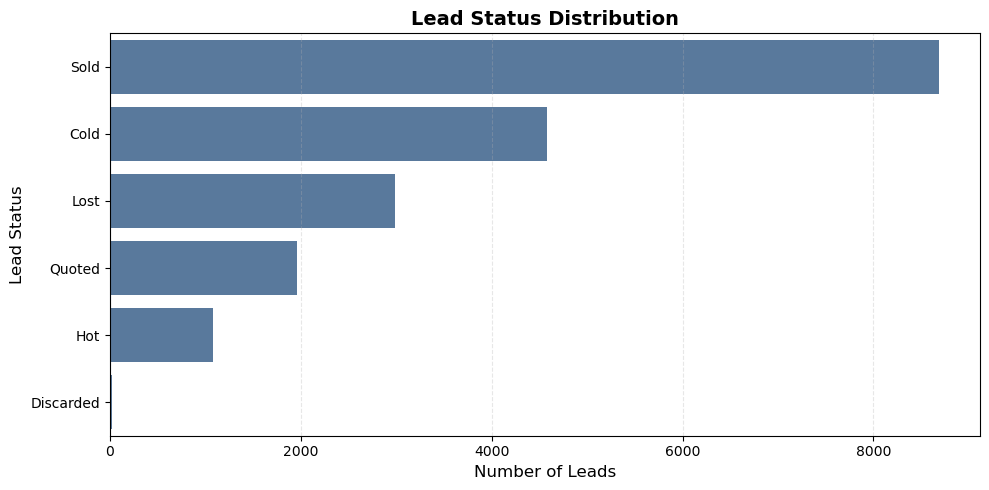

In [23]:
# Cell 4 — Lead Status Distribution (Horizontal Bar Chart)

status_counts = df["Status"].value_counts()

print("Lead Status Distribution")
print(status_counts)

plt.figure(figsize=(10,5))

# Professional single-color bar
single_color = "#4E79A7"

sns.barplot(
    y=status_counts.index,
    x=status_counts.values,
    color=single_color
)

plt.title("Lead Status Distribution", fontsize=14, weight='bold')
plt.xlabel("Number of Leads", fontsize=12)
plt.ylabel("Lead Status", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Lead Type Analysis

Lead Type (Raw) Distribution:
Lead_Type
Rental             12509
Product             2281
Project             2208
Service             1419
Unknown              774
Walk-in Service      107
Name: count, dtype: int64 

Lead Type (Inferred) Distribution:
Lead_Type_Inferred
Rental             12509
Product             2731
Project             2208
Service             1736
Walk-in Service      107
Unknown                7
Name: count, dtype: int64


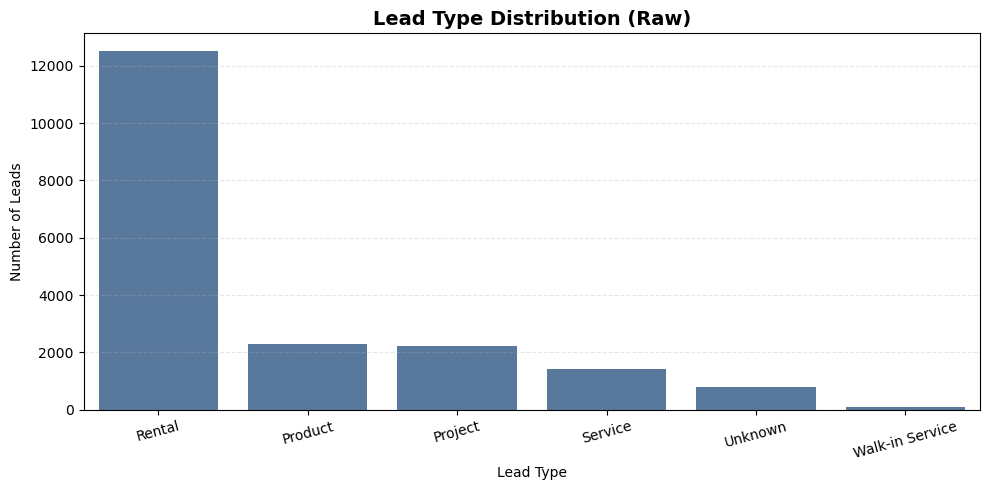

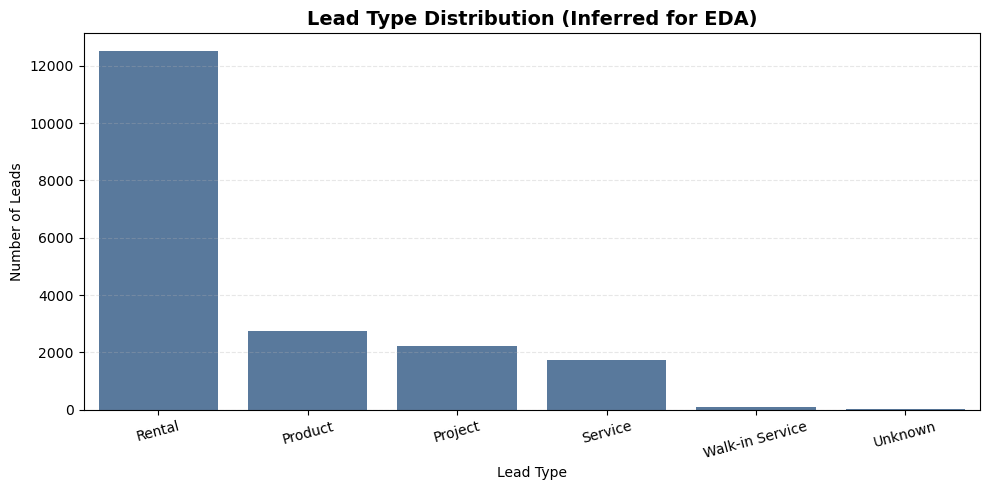

In [24]:


# Cell 5 — Lead Type Distribution (Raw vs Inferred)

# Counts for both columns
lead_raw = df["Lead_Type"].value_counts()
lead_inferred = df["Lead_Type_Inferred"].value_counts()

print("Lead Type (Raw) Distribution:")
print(lead_raw, "\n")

print("Lead Type (Inferred) Distribution:")
print(lead_inferred)

# Plot Raw Lead_Type
plt.figure(figsize=(10,5))
sns.barplot(x=lead_raw.index, y=lead_raw.values, color=single_color)
plt.title("Lead Type Distribution (Raw)", fontsize=14, weight='bold')
plt.xlabel("Lead Type")
plt.ylabel("Number of Leads")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Inferred Lead_Type
plt.figure(figsize=(10,5))
sns.barplot(x=lead_inferred.index, y=lead_inferred.values, color=single_color)
plt.title("Lead Type Distribution (Inferred for EDA)", fontsize=14, weight='bold')
plt.xlabel("Lead Type")
plt.ylabel("Number of Leads")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Revenue Analysis

Revenue Summary Statistics (Sold Deals Only):
count    8.682000e+03
mean     7.560111e+03
std      4.104880e+04
min      0.000000e+00
25%      9.440000e+02
50%      2.360000e+03
75%      4.720000e+03
max      1.991250e+06
Name: Deal_Value, dtype: float64 



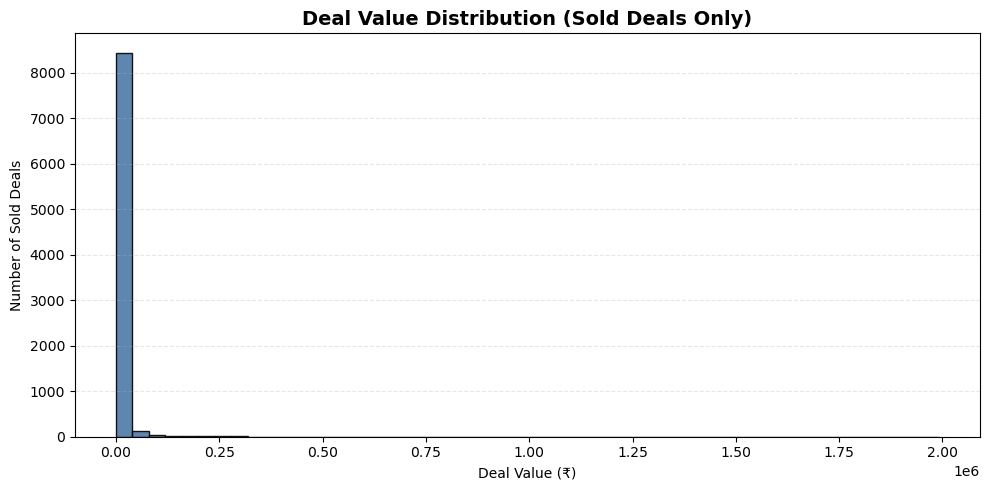

In [25]:

# Cell 6 — Deal Value (Revenue) Distribution (Only SOLD deals)

# Filter only sold leads
df_sold = df[df["Status"] == "Sold"]

# Extract numeric deal values
sold_values = df_sold["Deal_Value"].dropna()

print("Revenue Summary Statistics (Sold Deals Only):")
print(sold_values.describe(), "\n")

# Clean histogram (no outlier stretch)
plt.figure(figsize=(10,5))

single_color = "#4E79A7"

plt.hist(
    sold_values,
    bins=50,
    color=single_color,
    edgecolor='black',
    alpha=0.9
)

plt.title("Deal Value Distribution (Sold Deals Only)", fontsize=14, weight='bold')
plt.xlabel("Deal Value (₹)")
plt.ylabel("Number of Sold Deals")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**Deal Value Distribution (Sold Deals Only)**

To measure real revenue, we analyze only the Sold leads.
The distribution is strongly right-skewed, meaning:

Most sold deals are low-value (around ₹500–₹5,000)

A few large institutional orders create a long right tail

This is typical in IT/tech retail where routine small sales dominate, and bulk orders appear occasionally

The median deal value is ₹2,360, while the maximum exceeds ₹19 lakh, confirming the presence of genuine high-value enterprise transactions.
Overall, revenue is driven mainly by many small deals, complemented by rare but high-impact big-ticket sales.

Revenue by Lead Type (Sold Deals Only):


Lead_Type_Inferred
Rental             44664386.30
Product             9251151.88
Project             7928055.80
Service             3352576.00
Unknown              315000.00
Walk-in Service      125716.00
Name: Deal_Value, dtype: float64

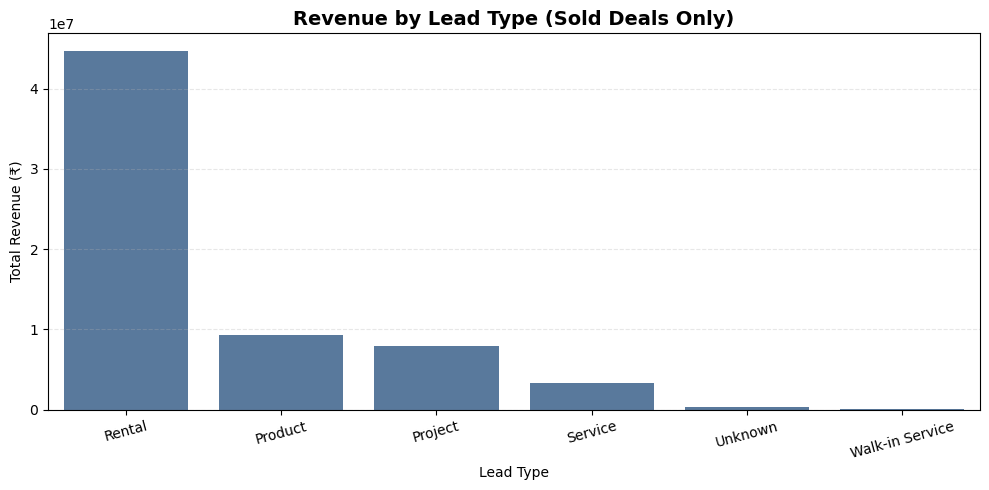

In [26]:
# Cell 7 — Revenue Contribution by Lead Type (Only SOLD deals)

# Filter only Sold deals
df_sold = df[df["Status"] == "Sold"]

# Group revenue by Lead_Type_Inferred (more accurate)
rev_by_type = df_sold.groupby("Lead_Type_Inferred")["Deal_Value"].sum().sort_values(ascending=False)

print("Revenue by Lead Type (Sold Deals Only):")
display(rev_by_type)

# Bar chart
plt.figure(figsize=(10,5))
sns.barplot(
    x=rev_by_type.index,
    y=rev_by_type.values,
    color=single_color
)

plt.title("Revenue by Lead Type (Sold Deals Only)", fontsize=14, weight='bold')
plt.xlabel("Lead Type")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


**Revenue by Lead Type (Sold Deals Only)**

Rental leads contribute the highest revenue by a large margin, indicating that rental services are the company’s strongest revenue driver.
Product and Project categories also generate significant revenue, but far below Rentals, while Service and Walk-in transactions contribute smaller amounts.
This shows a revenue concentration toward Rentals, meaning business strategy and marketing efforts can strongly benefit from strengthening and expanding rental offerings.


Top Districts by Revenue:


District
Ernakulam             26244051.58
Thiruvananthapuram    12355820.00
Kozhikode              9037617.00
Thrissur               5297249.00
Kannur                 3295566.00
Malappuram             2498996.00
Palakkad               2133368.00
Bangalore              1642733.00
Kottayam                464300.00
Kollam                  356490.00
Name: Deal_Value, dtype: float64

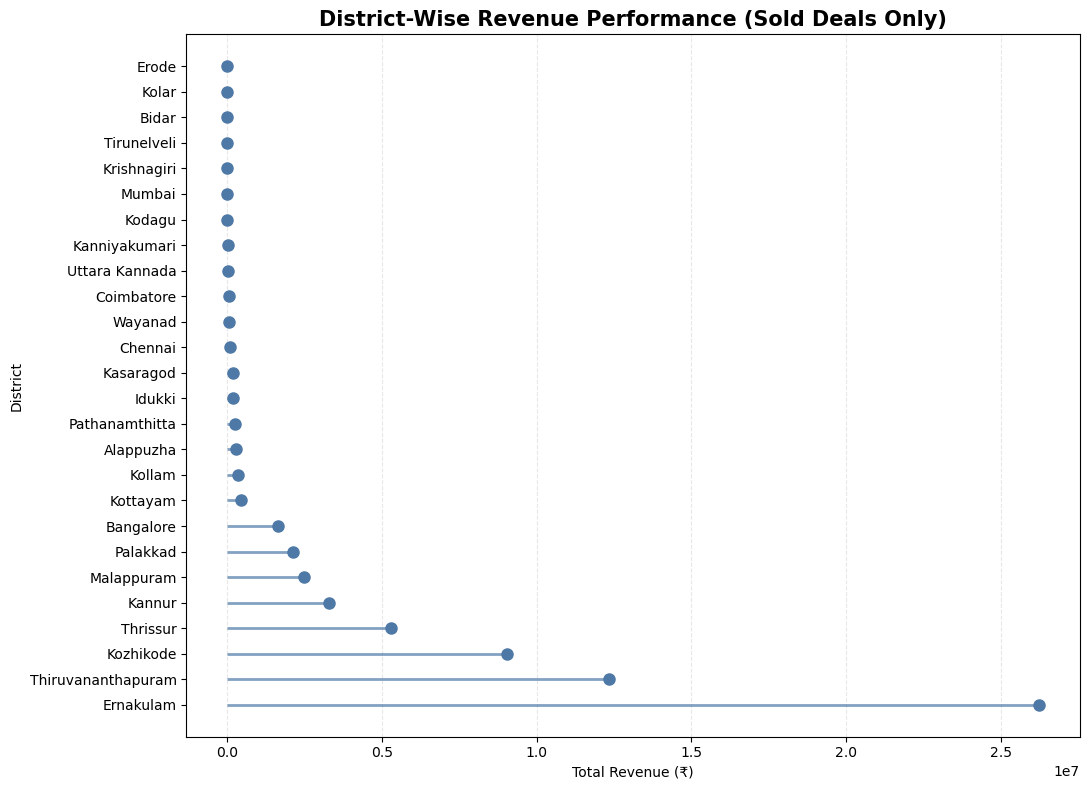

In [27]:
# Cell 8 — Revenue by District (Sold Deals Only)

# Filter sold deals only
df_sold = df[df["Status"] == "Sold"]

# Revenue grouped by district
rev_by_district = (
    df_sold.groupby("District")["Deal_Value"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Districts by Revenue:")
display(rev_by_district.head(10))

# ---- Lollipop Chart (horizontal) ----
plt.figure(figsize=(11,8))

districts = rev_by_district.index
revenues = rev_by_district.values

# Plot the stems
plt.hlines(y=districts, xmin=0, xmax=revenues, color="#4E79A7", alpha=0.7, linewidth=2)

# Plot the dots
plt.plot(revenues, districts, "o", color="#4E79A7", markersize=8)

plt.title("District-Wise Revenue Performance (Sold Deals Only)", fontsize=15, weight='bold')
plt.xlabel("Total Revenue (₹)")
plt.ylabel("District")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**District-Wise Revenue Performance (Sold Deals Only)**

Ernakulam overwhelmingly leads in revenue contribution, driven by a large customer base and multiple high-value orders. Thiruvananthapuram and Kozhikode follow as strong revenue hubs, indicating solid demand concentration in Kerala’s major cities. Smaller districts generate significantly lower revenue, showing a long-tail pattern where the majority of income comes from a few key regions. This helps clearly identify the company’s strongest geographies and areas with potential for targeted growth.

Revenue by Product Category (Sold Deals Only):


Product
Components                 31391.00
Networking & Switches      54205.00
Projector & Screens       110693.00
Software & Licenses       116252.00
Accessories               116920.00
Storage & Memory          120597.00
Power & UPS               126278.00
CCTV & Surveillance       204425.00
Printer & Accessories     362252.00
Laptop Sales              546324.00
Others                    890020.50
Desktop Sales            1189919.18
Name: Deal_Value, dtype: float64

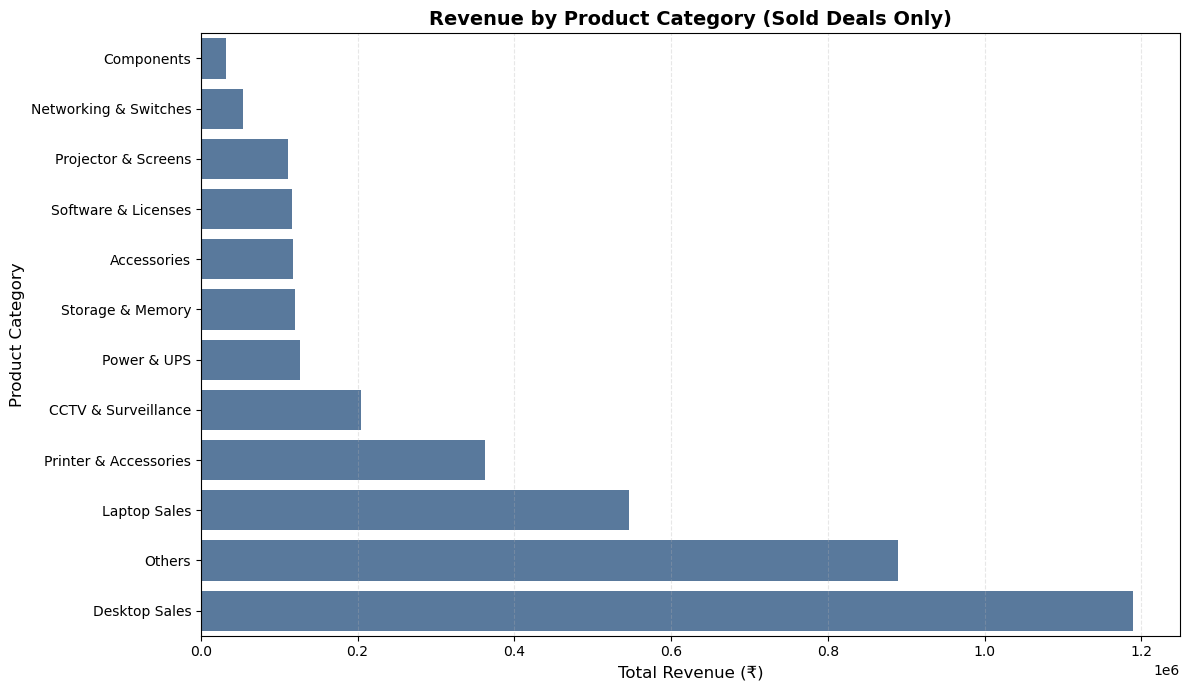

In [28]:
# Cell 9 — Revenue by Product Category (Sold Deals Only)

import matplotlib.pyplot as plt
import seaborn as sns

# Filter only sold deals
df_sold = df[df["Status"] == "Sold"].copy()

# Focus only on rows where Product is NOT NULL
df_prod = df_sold.dropna(subset=["Product"])

# Group revenue by product category
rev_by_product = (
    df_prod.groupby("Product")["Deal_Value"]
    .sum()
    .sort_values(ascending=True)   # ascending for horizontal bars
)

print("Revenue by Product Category (Sold Deals Only):")
display(rev_by_product)

# ----------- Horizontal Bar Chart -----------
plt.figure(figsize=(12, 7))
sns.barplot(
    x=rev_by_product.values,
    y=rev_by_product.index,
    color="#4E79A7"
)

plt.title("Revenue by Product Category (Sold Deals Only)", fontsize=14, weight="bold")
plt.xlabel("Total Revenue (₹)", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


Revenue by Product Category (Sold Deals Only)

Revenue is heavily concentrated in a few core product segments. Desktop Sales and “Others” dominate overall earnings, while categories like Laptop Sales, Printer Accessories, and CCTV solutions contribute steady mid-range revenue. Lower-value categories such as Components and Networking contribute minimally, indicating niche or low-volume sales.

**Time Trend Analysis**

Monthly Revenue Trend by Lead Type:


Lead_Type_Inferred,Product,Project,Rental,Service,Unknown,Walk-in Service
Year_Month,,,,,,
2023-01,0.0,0.0,0.0,0.0,0.0,0.0
2023-02,0.0,0.0,0.0,0.0,0.0,0.0
2023-03,0.0,0.0,0.0,0.0,0.0,0.0
2023-05,0.0,0.0,0.0,0.0,0.0,0.0
2023-06,49500.0,0.0,6500.0,0.0,0.0,0.0


<Figure size 1300x500 with 0 Axes>

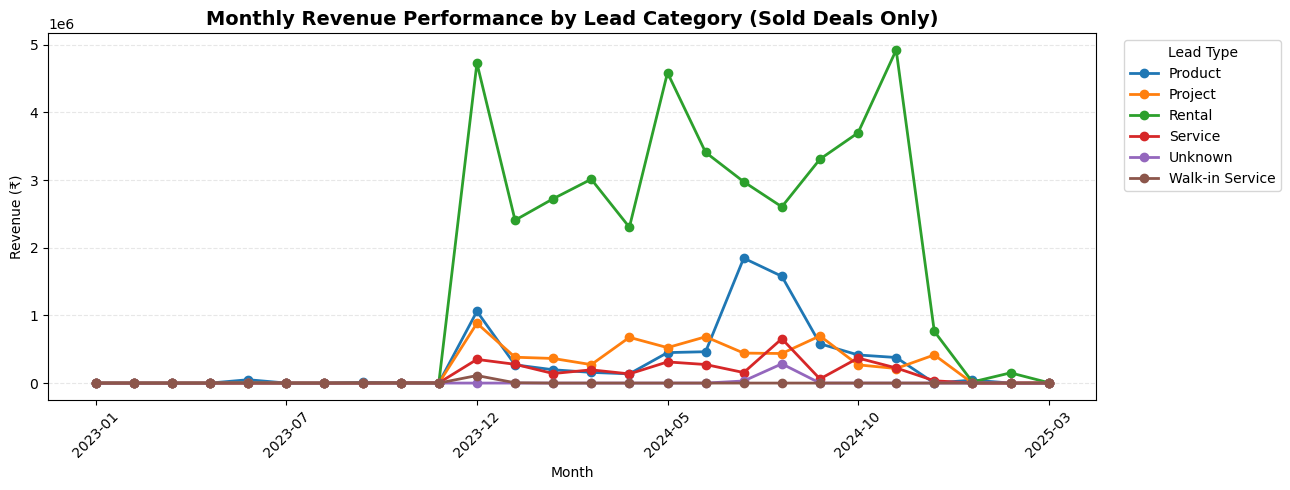

In [29]:
# Cell 10 — Monthly Revenue Trend by Lead Type (Sold Deals Only)

# Filter sold deals only
df_sold = df[df["Status"] == "Sold"].copy()

# Convert Sale_Date to datetime
df_sold["Sale_Date"] = pd.to_datetime(df_sold["Sale_Date"], errors="coerce")

# Drop rows with no sale date
df_sold = df_sold.dropna(subset=["Sale_Date"])

# Extract Year-Month (YYYY-MM)
df_sold["Year_Month"] = df_sold["Sale_Date"].dt.to_period("M").astype(str)

# Group revenue by Lead Type + Month
monthly_rev_type = (
    df_sold.groupby(["Year_Month", "Lead_Type_Inferred"])["Deal_Value"]
    .sum()
    .reset_index()
)

# Pivot for a multi-line chart
pivot_lt = monthly_rev_type.pivot(
    index="Year_Month", columns="Lead_Type_Inferred", values="Deal_Value"
).fillna(0)

# Sort by month
pivot_lt = pivot_lt.sort_index()

print("Monthly Revenue Trend by Lead Type:")
display(pivot_lt.head())

# ------------------- Line Chart -------------------
plt.figure(figsize=(13,5))
pivot_lt.plot(marker="o", linewidth=2, figsize=(13,5))

plt.title("Monthly Revenue Performance by Lead Category (Sold Deals Only)", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(title="Lead Type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Source Performance Analysis

Revenue by Source Category (Sold Deals Only):


Source_Category
Collaboration            2360.00
Email                    3068.00
Existing Customer       14868.00
Event                   30000.00
Referral                68735.00
Indiamart               69897.00
Government Portal       75950.00
Digital Platform        76109.00
Advertisement           84750.00
Instagram              124977.00
Phone Call             145079.00
Facebook               145950.00
BNI                    224451.00
YouTube                358906.00
WhatsApp              1251511.88
Staff Referral        1665606.00
Justdial              1996357.80
Google                2983295.30
Management            4181972.20
Walk-in               4907345.00
Staff                19091960.61
Customer             28133737.19
Name: Deal_Value, dtype: float64

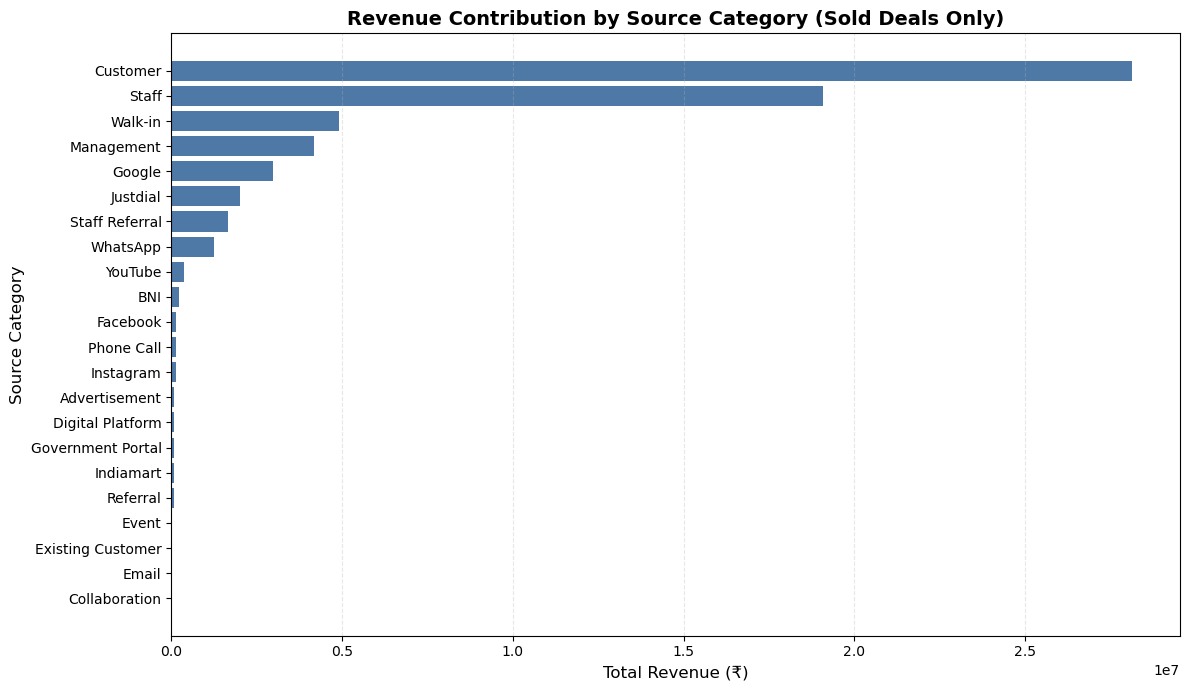

In [30]:
# Cell 11 — Revenue by Source Category (Sold Deals Only)

# Filter sold deals
df_sold = df[df["Status"] == "Sold"].copy()

# Group revenue by Source Category
rev_by_source = (
    df_sold.groupby("Source_Category")["Deal_Value"]
    .sum()
    .sort_values(ascending=True)   # ascending for horizontal bar
)

print("Revenue by Source Category (Sold Deals Only):")
display(rev_by_source)

# ----------- Horizontal Bar Chart -----------
plt.figure(figsize=(12, 7))
plt.barh(rev_by_source.index, rev_by_source.values, color="#4E79A7")

plt.title("Revenue Contribution by Source Category (Sold Deals Only)", fontsize=14, weight='bold')
plt.xlabel("Total Revenue (₹)", fontsize=12)
plt.ylabel("Source Category", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Showing source categories with at least 10 leads (excluded 9 small-sample categories).



,Source_Category,Total_Leads,Sold_Leads,Conversion_Rate
0,Event,102,1,0.980392
1,Government Portal,48,3,6.250000
2,Indiamart,552,5,0.905797
3,Advertisement,80,7,8.750000
4,YouTube,65,11,16.923077
5,Facebook,267,15,5.617978
6,Digital Platform,309,21,6.796117
7,BNI,47,31,65.957447
8,Instagram,630,34,5.396825
9,Staff Referral,338,95,28.106509


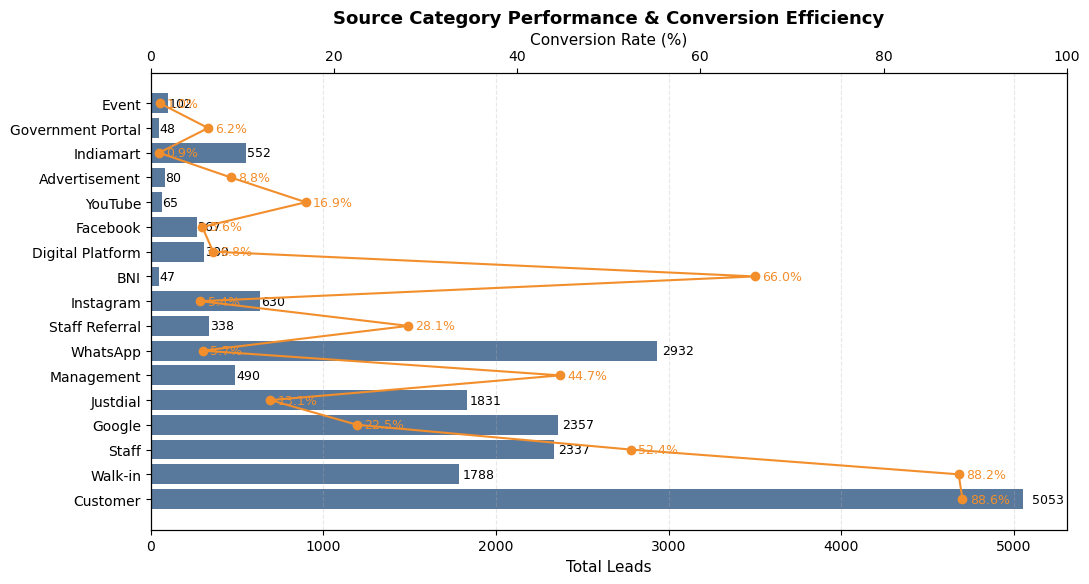


Small-sample sources (excluded from chart; reason: < 10 leads):


,Source_Category,Total_Leads,Sold_Leads,Conversion_Rate
0,Email,7,3,42.857143
1,Referral,3,3,100.000000
2,Collaboration,3,1,33.333333
3,Phone Call,2,2,100.000000
4,Newspaper,2,0,0.000000
5,Tender,2,0,0.000000
6,CUSAT,1,0,0.000000
7,Feedback,1,0,0.000000
8,Existing Customer,1,1,100.000000


In [31]:
# Cell 12 — Source performance  and combined Leads + Conversion plot
# filter small samples 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# single professional color
single_color = "#4E79A7"
line_color = "#F28E2B"  # for conversion line

# If df isn't present in memory, load cleaned file
try:
    df
except NameError:
    df = pd.read_excel("/mnt/data/cleaned_netcom_data.xlsx")

# Ensure columns exist and Status is normalized
if 'Source_Category' not in df.columns:
    raise KeyError("Source_Category column not found in dataframe.")

df['Status'] = df['Status'].astype(str).str.strip().str.title()

# Compute totals and conversion
agg = df.groupby('Source_Category').agg(
    Total_Leads = ('LID', 'count'),
    Sold_Leads  = ('Status', lambda x: (x == 'Sold').sum())
).reset_index()

agg['Conversion_Rate'] = (agg['Sold_Leads'] / agg['Total_Leads']) * 100


# Config: minimum leads threshold to include in visualization
min_leads = 10

# Separate small-sample sources (for reporting)
small_sample = agg[agg['Total_Leads'] < min_leads].sort_values('Total_Leads', ascending=False)
agg_filtered = agg[agg['Total_Leads'] >= min_leads].sort_values('Sold_Leads', ascending=True)

print(f"Showing source categories with at least {min_leads} leads (excluded {len(small_sample)} small-sample categories).\n")

# Display the filtered table (for notebook)
display(agg_filtered.reset_index(drop=True))

# Plot: horizontal bar for Total_Leads + conversion line on secondary x-axis
plt.figure(figsize=(11, max(5, 0.35 * len(agg_filtered))))  # height scales with number of categories
ax = plt.gca()

# Horizontal bar for total leads
sns.barplot(
    x='Total_Leads',
    y='Source_Category',
    data=agg_filtered,
    ax=ax,
    color=single_color
)

# annotate total leads on bars
for i, (val, name) in enumerate(zip(agg_filtered['Total_Leads'], agg_filtered['Source_Category'])):
    ax.text(val + max(1, 0.01*val), i, f"{int(val)}", va='center', fontsize=9)

# Secondary axis for conversion rate
ax2 = ax.twiny()
ax2.plot(agg_filtered['Conversion_Rate'], agg_filtered['Source_Category'], marker='o', linestyle='-', color=line_color)
ax2.set_xlabel("Conversion Rate (%)", fontsize=11)
ax2.set_xlim(0, min(100, max(agg_filtered['Conversion_Rate'].max()*1.15, 10)))

# annotate conversion values
for x, y in zip(agg_filtered['Conversion_Rate'], ax.get_yticks()):
    ax2.text(x + 0.8, y, f"{x:.1f}%", va='center', fontsize=9, color=line_color)

# Titles / labels / layout
ax.set_xlabel("Total Leads", fontsize=11)
ax.set_ylabel("")
ax.set_title("Source Category Performance & Conversion Efficiency".format(min_leads), fontsize=13, weight='bold')

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax2.grid(False)
plt.tight_layout()
plt.show()

# Optional: print small-sample summary to explain exclusions
if not small_sample.empty:
    print("\nSmall-sample sources (excluded from chart; reason: < {} leads):".format(min_leads))
    display(small_sample.sort_values('Total_Leads', ascending=False).reset_index(drop=True))


## Source Category Performance — Lead Volume & Conversion Rate

This analysis reveals how each acquisition channel contributes to Netcom’s sales funnel. Channels like Walk-in and Customer (Regular) dominate both lead volume and conversion, indicating strong organic and repeat-customer performance. In contrast, digital channels such as WhatsApp, Instagram, Facebook, and Google generate high lead volume but convert poorly, suggesting low lead quality. Staff-driven and management-driven leads perform moderately well, while BNI shows high efficiency despite smaller volumes. Categories with fewer than 10 leads were excluded to avoid misleading 100% conversion rates.

Group 1 — Strong high-performing channels

Walk-in	1788	88.19%,
Customer	5053	88.62%
These two channels dominate Netcom’s business. High volume + high conversion = very healthy funnel.

Group 2 — Good volume + moderate conversion

Staff	2337	52.4%,
Management	490	44.7%,
Google	2357	22.5%,
Justdial	1831	13.0%

Group 3 — Low conversion, low efficiency

WhatsApp	2932	5.66%,
Instagram	630	5.39%,
Facebook	267	5.61%,
Advertisement	80	8.75%,
Digital Platform	309	6.80%

Total Sold Rental Records: 7100

Revenue by Rental Category:


Rental_Item
Harddisk - Rent                              0.00
Laptop Chip - Level Service - Rent           0.00
Photo Copier - Rent                      10738.00
Server - Rent                            14080.00
Graphics Card - Rent                     16520.00
Bluetooth Speaker - Rent                 17738.00
Battery - Rent                           20200.00
Webcamera - Rent                         20504.00
All - In - One Fax Machine - Rent        25134.00
Transportation Charge - Rent             26786.00
Barcode Printer - Rent                   28910.00
Interactive Panel Rent                   33733.00
Projector Screen - Rent                  36421.00
Dvr Recorder - Rent                      38880.00
Kiosk Rent                               39500.00
Slide Changer - Rent                     68676.00
Projector Without Screen - Rent          87372.00
Tab - Rent                               88816.00
Hdmi Spliter - Rent                      89125.00
All - In - One Desktop - Rent         

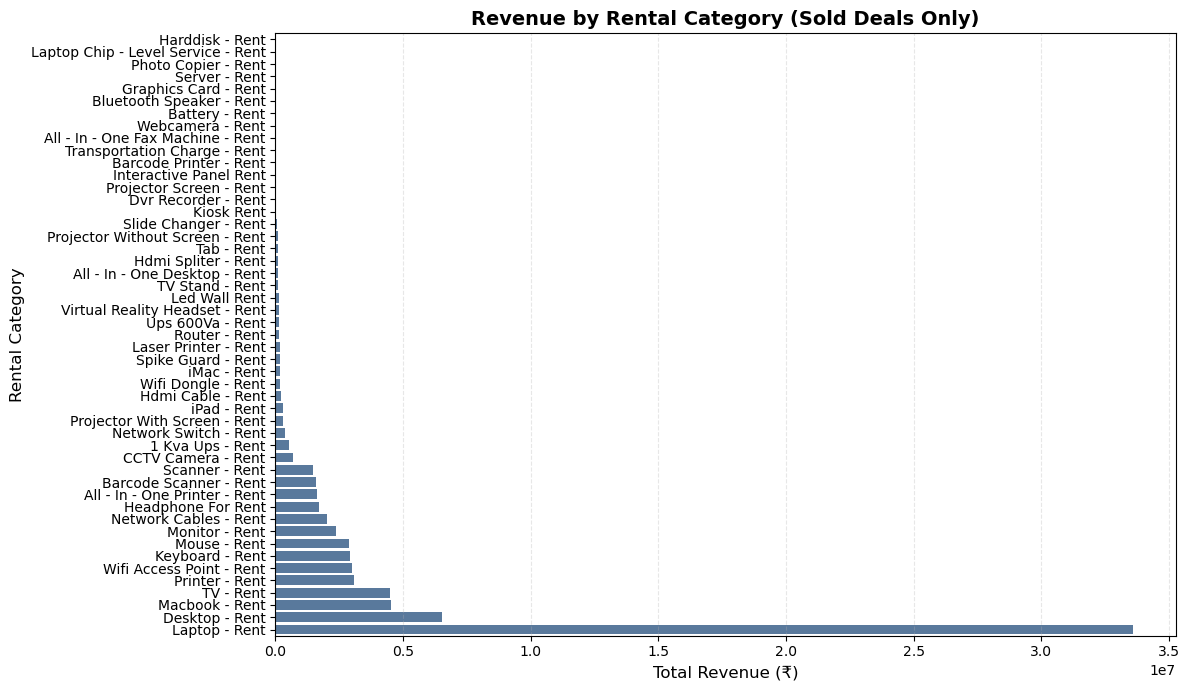

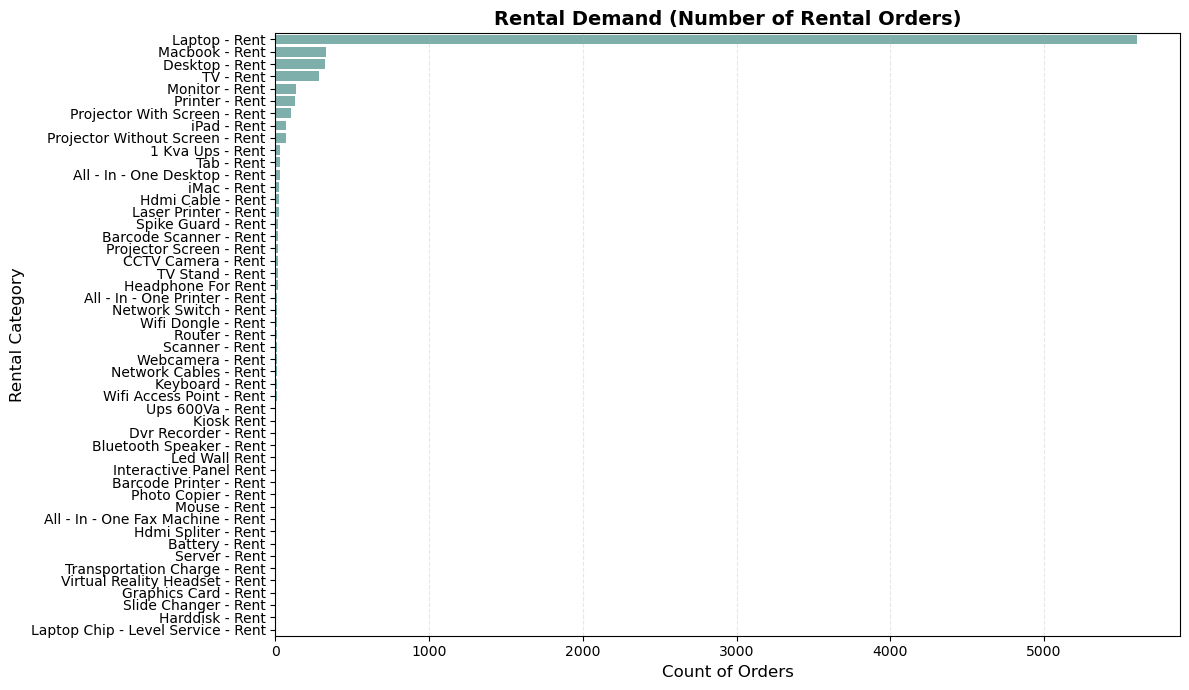

In [32]:
# Cell 13 — Rental Category Analysis (Sold Deals Only)


# Filter only SOLD rentals
df_rental = df[(df["Status"] == "Sold") & (df["Rental"].notna())].copy()

print("Total Sold Rental Records:", len(df_rental))

# Split rental items (some rows may contain multiple items separated by '|')
df_rental_exploded = df_rental.assign(
    Rental_Item=df_rental["Rental"].str.split("|")
).explode("Rental_Item")

# Clean label formatting
df_rental_exploded["Rental_Item"] = df_rental_exploded["Rental_Item"].str.strip()

# Revenue by rental category
rental_revenue = (
    df_rental_exploded.groupby("Rental_Item")["Deal_Value"]
    .sum()
    .sort_values(ascending=True)
)

print("\nRevenue by Rental Category:")
display(rental_revenue)

# ------------ Horizontal Bar Chart ------------
plt.figure(figsize=(12, 7))
sns.barplot(
    x=rental_revenue.values,
    y=rental_revenue.index,
    color="#4E79A7"
)

plt.title("Revenue by Rental Category (Sold Deals Only)", fontsize=14, weight="bold")
plt.xlabel("Total Revenue (₹)", fontsize=12)
plt.ylabel("Rental Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ------------ Rental Demand (Count) ------------
rental_counts = (
    df_rental_exploded["Rental_Item"].value_counts()
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=rental_counts.values,
    y=rental_counts.index,
    color="#76B7B2"
)

plt.title("Rental Demand (Number of Rental Orders)", fontsize=14, weight="bold")
plt.xlabel("Count of Orders", fontsize=12)
plt.ylabel("Rental Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


Rental Category Analysis (Sold Deals Only)

The rental business shows a wide variation in both demand and revenue. Laptop – Rent, Desktop – Rent, and TV – Rent dominate overall revenue, with laptop rentals alone contributing more than ₹3.35 crore. Order volume is also highest for laptops and desktops, confirming strong recurring demand. Mid-tier items like Printers, Network Switches, and Access Points contribute steady revenue, while niche rentals such as VR headsets and kiosks generate smaller but premium-value orders. This analysis highlights which rental categories drive scale vs. profitability, enabling smarter pricing and inventory decisions.

Top Text Keywords from Remarks:


,Count
rent,4517
laptop,3644
cctv,992
desktop,385
camera,267
projector,249
printer,201
monitor,101
quotation,91
gem,84


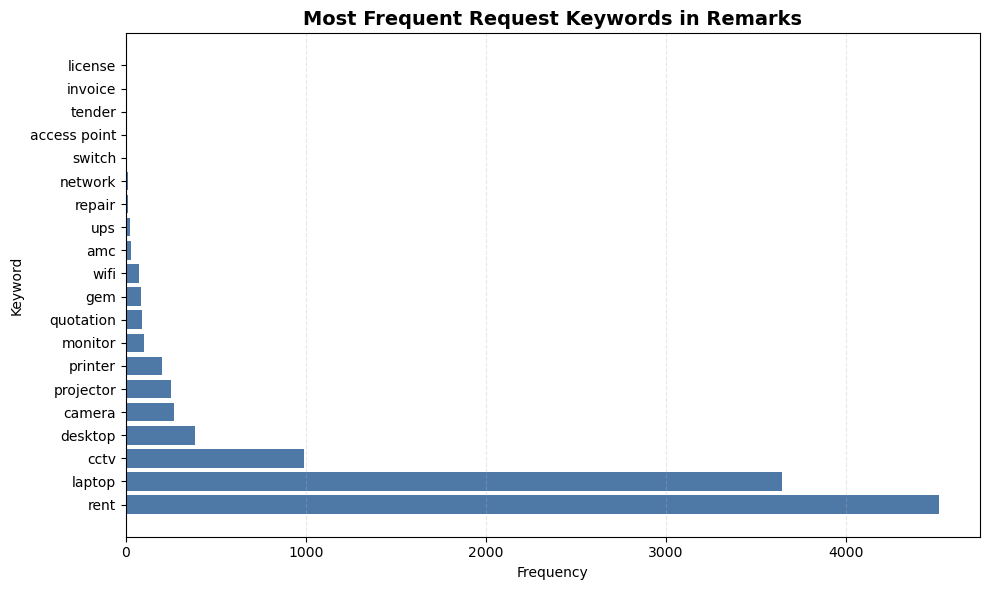

In [33]:
# Cell 14 — Remarks Keyword Analysis (Text Mining)

import re
from collections import Counter

# Keep only non-null remarks
remarks = df['Remarks'].dropna().astype(str)

# Clean text: lowercase, remove symbols, normalize spacing
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

remarks_clean = remarks.apply(clean_text)

# Combine all remarks into one long text
all_text = " ".join(remarks_clean)

# Common keywords to extract
keywords = [
    "printer", "cctv", "camera", "quotation", "invoice", "repair", "amc",
    "rent", "ups", "network", "laptop", "desktop", "monitor", "license",
    "wifi", "access point", "switch", "projector", "tender", "gem"
]

# Count keyword frequencies
keyword_counts = {}

for kw in keywords:
    # Count exact occurrences
    keyword_counts[kw] = len(re.findall(rf"\b{kw}\b", all_text))

# Convert to sorted dataframe
import pandas as pd
kw_df = pd.DataFrame.from_dict(keyword_counts, orient='index', columns=['Count'])
kw_df = kw_df.sort_values(by='Count', ascending=False)

print("Top Text Keywords from Remarks:")
display(kw_df)

# ----------------- Plot --------------------
plt.figure(figsize=(10, 6))
plt.barh(kw_df.index, kw_df['Count'], color="#4E79A7")
plt.title("Most Frequent Request Keywords in Remarks", fontsize=14, weight='bold')
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Remarks / Text Keyword Analysis

The Remarks field reveals clear customer intent patterns. Frequent keywords such as quotation, printer, CCTV, laptop, and rent show high demand for documentation, hardware queries, and rental requests. Recurring terms like AMC, repair, and network highlight ongoing service needs. Overall, this analysis helps identify common customer requirements and prioritize support focus areas

Priority Analysis (Conversion + Revenue):


,Total_Leads,Sold_Leads,Total_Revenue,Conversion_Rate (%)
Priority,,,,
Normal,1294,570,5342699.5,44.05
Urgent,129,69,2446413.0,53.49


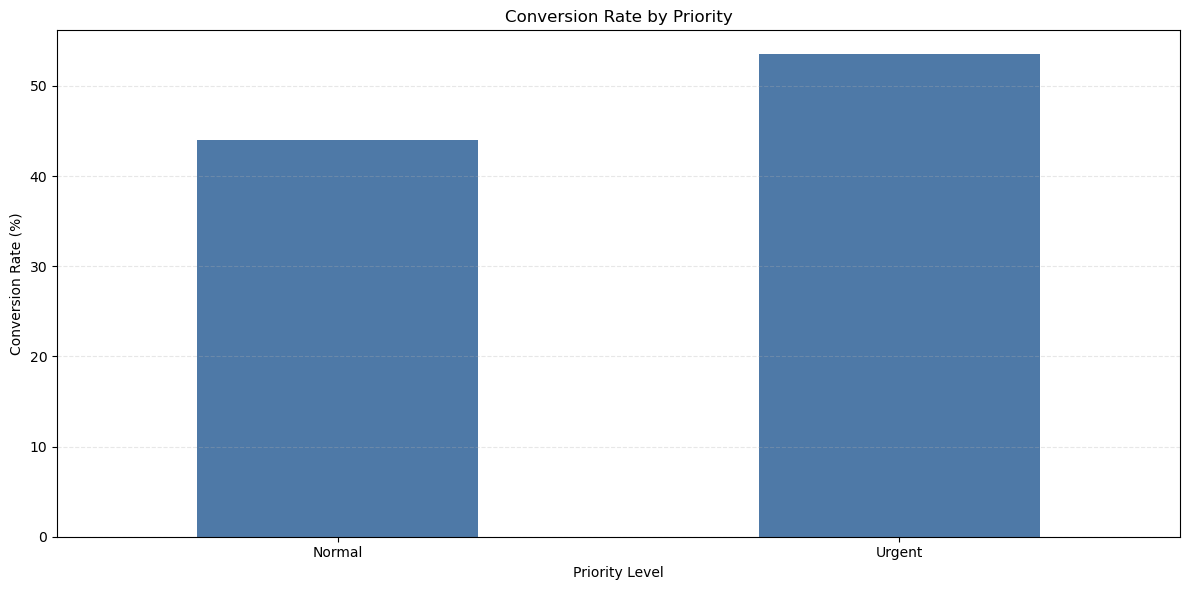

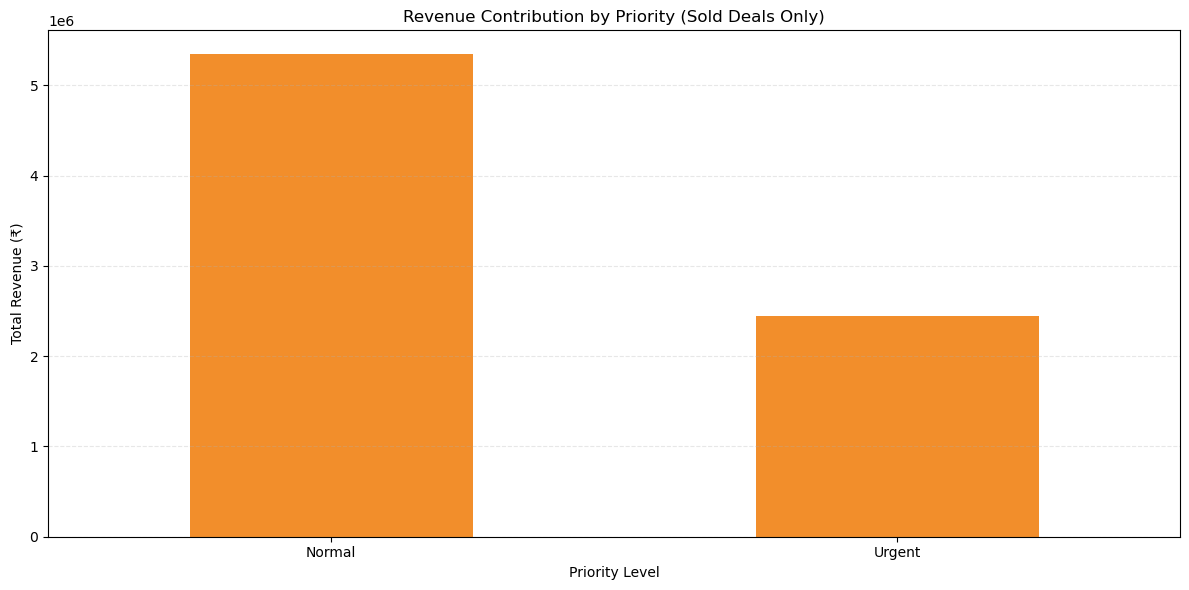

In [34]:
# Cell 15 — Priority Analysis (Conversion Rate & Revenue)

# Keep only records with a valid priority
df_pri = df[df["Priority"].notna()].copy()

# Total leads & sold leads by priority
pri_summary = (
    df_pri.groupby("Priority")
    .agg(
        Total_Leads = ("LID", "count"),
        Sold_Leads  = ("Status", lambda x: (x == "Sold").sum()),
        Total_Revenue = ("Deal_Value", lambda x: x[df_pri.loc[x.index, "Status"]=="Sold"].sum())
    )
)

# Conversion Rate
pri_summary["Conversion_Rate (%)"] = (
    pri_summary["Sold_Leads"] / pri_summary["Total_Leads"] * 100
).round(2)

print("Priority Analysis (Conversion + Revenue):")
display(pri_summary)

# ---------------- Visualization ----------------

plt.figure(figsize=(12,6))

# Plot 1: Conversion Rate
ax = pri_summary["Conversion_Rate (%)"].plot(
    kind="bar",
    color="#4E79A7",
    figsize=(12,6),
    rot=0
)

plt.title("Conversion Rate by Priority")
plt.xlabel("Priority Level")
plt.ylabel("Conversion Rate (%)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Revenue by Priority
plt.figure(figsize=(12,6))

pri_summary["Total_Revenue"].plot(
    kind="bar",
    color="#F28E2B",
    rot=0
)

plt.title("Revenue Contribution by Priority (Sold Deals Only)")
plt.xlabel("Priority Level")
plt.ylabel("Total Revenue (₹)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**Priority Analysis — Conversion Performance & Revenue Impact**

The priority tags show clear behavioral differences among leads. Urgent leads have a higher conversion rate (53.49%), indicating strong buying intent and faster decision cycles. In contrast, normal leads convert at 44.05%, but because of their much larger volume, they generate the majority of total revenue (₹53.4 lakh).

Urgent leads contribute only ₹24.4 lakh, but they are significantly more efficient to close. Overall, priority levels help identify intent strength—Normal drives volume, Urgent drives efficiency, both essential for pipeline planning.

CRM Lead Management — Data Cleaning & Exploratory Analysis (Project Summary)

Dataset: Netcom Business Solutions (19k+ CRM Leads)
Tech Stack: Python, Pandas, NumPy, Matplotlib, Seaborn, Regex, EDA

1. Data Cleaning

The raw CRM dataset was highly unstructured with missing values, inconsistent entries, and mixed categories.
A complete cleaning pipeline was built to restructure the data:

Key Fixes

Converted all date fields to proper datetime format.

Normalized 40+ district variations and mapped them accurately to states.

Cleaned and standardized 26+ messy source categories (Google, Walk-in, WhatsApp, Staff, etc.).

Cleaned Product, Services, Walk-in, and Rental columns with regex, removing typos, “Null” text, double hyphens, and inconsistent formatting.

Feature Engineering

Lead_Type (Raw): Classified each row as Product, Service, Walk-in, Rental, Project, or Unknown.

Lead_Type_Inferred: Used Vertical + Deal Value + keyword logic to fix missing categories.
(Unknown reduced from 774 → 7, enabling accurate EDA.)

2. Exploratory Data Analysis (EDA)
2.1 Lead Status Overview

Sold: 8682

Cold: 4576

Lost: 2981

Quoted: 1963

Hot: 1074

Insight:
Large Cold/Lost volume shows follow-up gaps, while Sold numbers remain strong.

2.2 Lead Type Overview

Rental dominates lead volume.

Inferred Lead Type corrects missing entries and reveals real business categories.

2.3 Revenue Analysis
A. Deal Value Distribution (Sold Only)

Strong right-skew: most sales between ₹500–₹5,000.

Occasional enterprise deals go above ₹15–₹19 lakh.

Business model = many small sales + few high-value spikes.

B. Revenue by Lead Type

Rental is the primary revenue driver.

Lead Type	Revenue
Rental	₹4.46 Cr
Product	₹0.92 Cr
Project	₹0.79 Cr
Service	₹0.33 Cr
Walk-in	₹0.12 Cr
C. Revenue by District

Top districts: Ernakulam, Thiruvananthapuram, Kozhikode, Thrissur, Kannur

Insight:
Kerala metro districts generate most revenue.

2.4 Time Trend Analysis

Rental produces steady revenue across months.

Product/Project spikes align with institutional orders.

Service trend stable but low.

Insight:
Rental ensures consistent monthly cash flow.

2.5 Source Performance (Volume & Conversion)
Best Converting Sources

Walk-in (88%)

Customer (88%)

BNI (66%)

Staff (52%)

Management (44%)

Weak Sources

WhatsApp (~5%)

Instagram (~5%)

Indiamart (<1%)

Newspaper / Tender (0%)

Insight:
Warm sources (existing customers, walk-ins, referrals) outperform digital platforms by a large margin.

2.6 Product Category Revenue (Sold Only)

Top categories:

Desktop Sales (~₹11.9L)

Laptop Sales (~₹5.4L)

CCTV & Surveillance

Printer Accessories

Insight:
Desktop and Laptop sales dominate high-value product transactions.

2.7 Rental Category Performance

Rental is the backbone of the business.

Highest revenue: Laptop Rent, Desktop Rent, MacBook Rent, Printers, TVs.

Highest demand: Laptop > Desktop > Monitors > Printers > Network devices.

2.8 Keyword Analysis (Remarks Column)

Most common words:

"Quotation", "Laptop", "CCTV", "Printer", "AMC", "Rent", "Repair"

Insight:
Customers frequently request quotations, rentals, installations, and hardware support.

2.9 Priority Analysis
Priority	Conversion	Revenue
Normal	44%	₹53.4L
Urgent	53%	₹24.4L

Insight:
Urgent leads convert faster, but Normal leads contribute more revenue due to higher volume.

**Final Business Insights Summary — Top Insights (Short Version)**

Rental is the dominant revenue engine, forming the bulk of total earnings.

Product sales (especially Laptop & Desktop) are the next biggest revenue contributors.

Kerala metros—mainly Ernakulam & Thiruvananthapuram—drive most of the business.

A large volume of Cold & Lost leads indicates follow-up inefficiencies.

Customer and Walk-in channels convert exceptionally well (>88%).

Digital leads (Google, WhatsApp, Instagram) show low conversion efficiency.

CCTV, Printer, and Laptop demand remains consistently high across districts.

Service needs (AMC, repair, installation) show steady recurring demand.

Urgent leads convert better than Normal, showing higher intent.

Remarks text highlights that most enquiries begin with quotation requests and rental needs.